In soda.F90, add the following declarations


character(len=20) :: filename
character(len=3) :: index_str  ! For 3-digit numbers
integer :: i

And this in correspondence of XF (line 850 for example)
write(index_str, '(I3.3)') NIFIC
filename = 'output_' // index_str // '.csv'
print*, filename
open(ISIZE_NATURE, file=trim(filename), status='replace')
write(ISIZE_NATURE, *) (XF(i,1,NIFIC,1), i=1, size(XF,1))  ! For 2D, writes rows as space-separated
close(ISIZE_NATURE)
! PRINT*, SHAPE(XF)

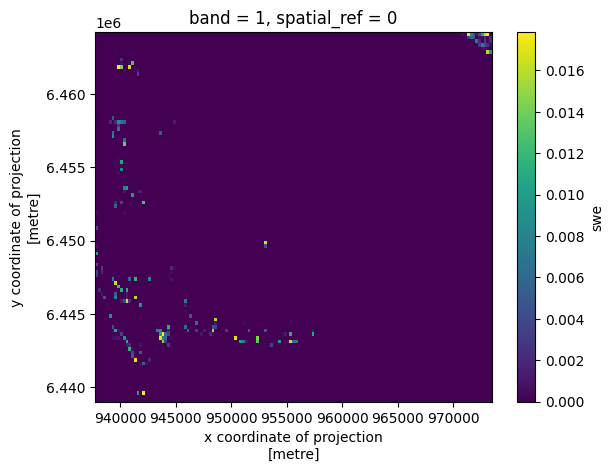

In [4]:
import numpy as np
import pandas as pd
from pyproj import CRS
from edelassim.postprocess_surfex.prep import compute_snow_thickness_and_mass_from_prep
from edelassim.observation_operators import zaitchik

folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
for mb in range(1, 18):
    if mb < 10:
        mb_str = f"0{mb}"
    else:
        mb_str = mb
    csv_file = f"{folder}/fsc_soda0{mb_str}.csv"
    df = pd.read_csv(csv_file, header=None)
    mb_fsc = np.flip(df.values.reshape(101, 143), axis=0)
    break

prep = compute_snow_thickness_and_mass_from_prep(
    f"{folder}/PREP_220226H12_PF_ENS1.nc",
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
    crs=CRS.from_epsg(2154),
)

fsc_prep = zaitchik(swe=prep.data_vars["swe"])

# plot y axis is fsc not swe
(fsc_prep - mb_fsc).plot.imshow()
(fsc_prep*0 + mb_fsc).to_netcdf('diff_fsc_mb0')

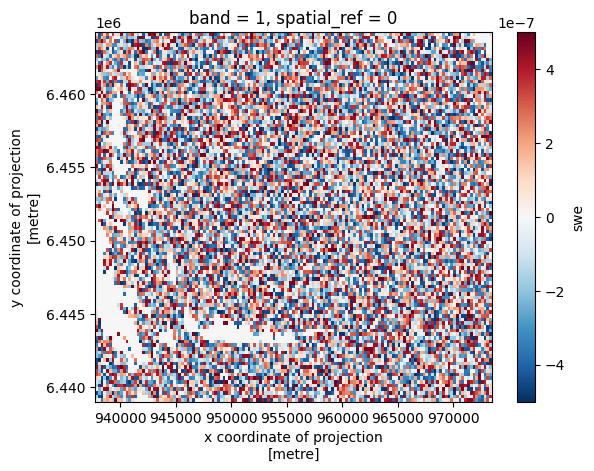

In [ ]:
import numpy as np
import pandas as pd
from pyproj import CRS
from edelassim.postprocess_surfex.prep import compute_snow_thickness_and_mass_from_prep
from edelassim.observation_operators import zaitchik

folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
for mb in range(5, 18):
    if mb < 10:
        mb_str = f"0{mb}"
    else:
        mb_str = mb
    csv_file = f"{folder}/swe_soda0{mb_str}.csv"
    df = pd.read_csv(csv_file, header=None)
    mb_swe = np.flip(df.values.reshape(101, 143), axis=0)
    break

prep = compute_snow_thickness_and_mass_from_prep(
    f"{folder}/PREP_220226H12_PF_ENS5.nc",
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
    crs=CRS.from_epsg(2154),
)

# fsc_prep = zaitchik(swe=prep.data_vars["swe"])

(prep["swe"] - mb_swe).plot.imshow()

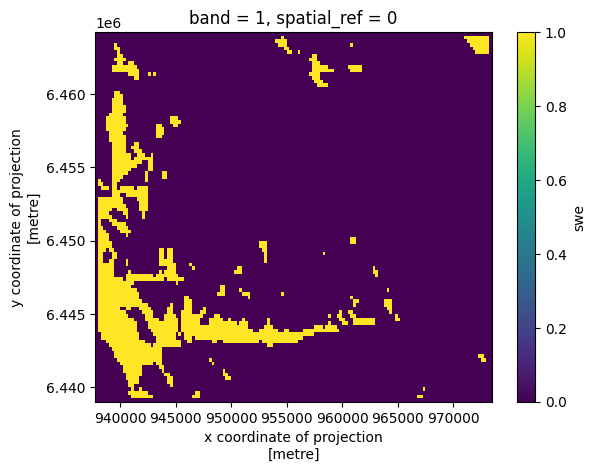

In [ ]:
(fsc_prep < 1).plot.imshow()